<a href="https://colab.research.google.com/github/jomanakhatib/Projects-/blob/main/Bachelor_Fina.1l.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# ===============================
# 1. Imports
# ===============================
import os
import glob
import math
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU devices: []


In [28]:
# ===============================
# 2. Reproducibility
# ===============================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 3. Upload files manually (optional)
# ===============================
from google.colab import files

# Uncomment only if needed:
# uploaded = files.upload()

# ===============================
# 4. Configuration
# ===============================

# Path where your uploaded CSV files exist in Colab
DATASET_ROOT = "/content"

# FAST_MODE:
# True  -> faster run for seminar demo
# False -> closer to full paper-style reimplementation
FAST_MODE = True

# Paper settings
INPUT_STEPS = 36   # 180 minutes / 5-min intervals
OUTPUT_STEPS = 12  # 60 minutes / 5-min intervals

# Training settings
if FAST_MODE:
    EPOCHS = 12
    BATCH_SIZE = 64
    PATIENCE = 3
else:
    EPOCHS = 50
    BATCH_SIZE = 32
    PATIENCE = 5

LEARNING_RATE = 0.001

# Save folder
SAVE_DIR = "/content/hupa_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "models"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "plots"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "tables"), exist_ok=True)

print("FAST_MODE:", FAST_MODE)
print("EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE, "PATIENCE:", PATIENCE)

# ===============================
# 5. Find patient CSV files
# ===============================
csv_files = sorted(glob.glob(os.path.join(DATASET_ROOT, "HUPA*.csv")))
print("Found CSV files:", len(csv_files))
print(csv_files[:10])

assert len(csv_files) > 0, "No HUPA CSV files found in /content. Upload them first."

FAST_MODE: True
EPOCHS: 12 BATCH_SIZE: 64 PATIENCE: 3
Found CSV files: 25
['/content/HUPA0001P.csv', '/content/HUPA0002P.csv', '/content/HUPA0003P.csv', '/content/HUPA0004P.csv', '/content/HUPA0005P.csv', '/content/HUPA0006P.csv', '/content/HUPA0007P.csv', '/content/HUPA0009P.csv', '/content/HUPA0010P.csv', '/content/HUPA0011P.csv']


In [29]:
# ===============================
# 6. Load and validate patient files
# ===============================
REQUIRED_COLS = [
    "glucose",
    "carb_input",
    "bolus_volume_delivered",
    "basal_rate"
]

patient_data = {}
bad_files = []

for f in csv_files:
    try:
        df = pd.read_csv(f, sep=';')

        if not all(col in df.columns for col in REQUIRED_COLS):
            bad_files.append((os.path.basename(f), list(df.columns)))
            continue

        temp = df[REQUIRED_COLS].copy()
        temp.columns = ["glucose", "carbs", "bolus", "basal"]

        # Convert to numeric safely
        for c in temp.columns:
            temp[c] = pd.to_numeric(temp[c], errors="coerce")

        temp = temp.dropna().reset_index(drop=True)

        # Remove impossible rows if any
        temp = temp[
            (temp["glucose"] >= 20) &
            (temp["glucose"] <= 600) &
            (temp["carbs"] >= 0) &
            (temp["bolus"] >= 0) &
            (temp["basal"] >= 0)
        ].reset_index(drop=True)

        if len(temp) >= 200:
            patient_id = os.path.splitext(os.path.basename(f))[0]
            patient_data[patient_id] = temp
        else:
            bad_files.append((os.path.basename(f), f"Too few usable rows: {len(temp)}"))

    except Exception as e:
        bad_files.append((os.path.basename(f), str(e)))

print("Loaded valid patient files:", len(patient_data))
print("Patient IDs:", list(patient_data.keys())[:10])

if bad_files:
    print("\nSome skipped/problem files:")
    for item in bad_files[:10]:
        print(item)
# ===============================
# 7. Preview one patient
# ===============================
sample_pid = list(patient_data.keys())[0]
print("Sample patient:", sample_pid)
display(patient_data[sample_pid].head())
print(patient_data[sample_pid].describe())

Loaded valid patient files: 25
Patient IDs: ['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P', 'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P']
Sample patient: HUPA0001P


,glucose,carbs,bolus,basal
0,332.0,0.0,0.0,0.091667
1,326.0,0.0,0.0,0.091667
2,330.0,0.0,0.0,0.091667
3,324.0,0.0,0.0,0.091667
4,306.0,0.0,0.0,0.075000


           glucose        carbs        bolus        basal
count  4096.000000  4096.000000  4096.000000  4096.000000
mean    181.443726     0.029541     0.038477     0.049675
std      70.644633     0.310549     0.344373     0.022216
min      40.000000     0.000000     0.000000     0.000000
25%     131.000000     0.000000     0.000000     0.037500
50%     165.666667     0.000000     0.000000     0.041667
75%     222.000000     0.000000     0.000000     0.070833
max     444.000000     4.000000     5.200000     0.091667


In [30]:
# ===============================
# 8. Helper functions
# ===============================
def chronological_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].reset_index(drop=True)
    val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
    test_df  = df.iloc[val_end:].reset_index(drop=True)

    return train_df, val_df, test_df


def scale_patient_data(train_df, val_df, test_df):
    scaler = MinMaxScaler()
    scaler.fit(train_df[["glucose", "carbs", "bolus", "basal"]])

    def transform(df):
        temp = df.copy()
        temp[["glucose", "carbs", "bolus", "basal"]] = scaler.transform(
            temp[["glucose", "carbs", "bolus", "basal"]]
        )
        return temp

    return transform(train_df), transform(val_df), transform(test_df), scaler


def make_sequences(df):
    X, y = [], []

    values = df[["glucose", "carbs", "bolus", "basal"]].values.astype(np.float32)
    glucose = df["glucose"].values.astype(np.float32)

    max_i = len(df) - INPUT_STEPS - OUTPUT_STEPS + 1
    for i in range(max_i):
        X.append(values[i:i + INPUT_STEPS])
        y.append(glucose[i + INPUT_STEPS:i + INPUT_STEPS + OUTPUT_STEPS])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def build_model():
    model = Sequential([
        Input(shape=(INPUT_STEPS, 4)),
        LSTM(50, activation="tanh"),
        Dense(32, activation="relu"),
        Dense(OUTPUT_STEPS)
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse"
    )
    return model


def inverse_glucose_only(y_scaled, scaler):
    flat = y_scaled.reshape(-1)
    dummy = np.zeros((len(flat), 4), dtype=np.float32)
    dummy[:, 0] = flat
    inv = scaler.inverse_transform(dummy)[:, 0]
    return inv.reshape(y_scaled.shape)


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten())))


# Clarke Error Grid zone classification
def clarke_error_zone(true_val, pred_val):
    # simplified standard logic
    if true_val < 70:
        if pred_val < 70:
            return "A"
        elif 70 <= pred_val <= 180:
            return "B"
        elif pred_val > 180:
            return "E"
    else:
        rel_err = abs(pred_val - true_val) / true_val
        if rel_err <= 0.20:
            return "A"
        elif ((true_val >= 70 and pred_val <= 70) or
              (true_val <= 180 and pred_val > 180)):
            return "B"

    # Further simplified rules for C/D/E
    if true_val >= 240 and 70 <= pred_val <= 180:
        return "D"
    if true_val <= 70 and pred_val >= 180:
        return "E"
    if pred_val >= true_val + 110 or pred_val <= true_val - 110:
        return "C"

    return "B"


def compute_clarke_percentages(y_true, y_pred):
    zones = {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0}
    flat_true = y_true.flatten()
    flat_pred = y_pred.flatten()

    for t, p in zip(flat_true, flat_pred):
        z = clarke_error_zone(float(t), float(p))
        zones[z] += 1

    total = len(flat_true)
    for z in zones:
        zones[z] = 100.0 * zones[z] / total
    return zones

In [31]:
# ===============================
# 9. Prepare splits and sequences
# ===============================
patient_splits = {}
patient_scalers = {}

all_train_X, all_train_y = [], []
all_val_X, all_val_y = [], []

for pid, df in patient_data.items():
    train_df, val_df, test_df = chronological_split(df)
    train_df_s, val_df_s, test_df_s, scaler = scale_patient_data(train_df, val_df, test_df)

    X_train, y_train = make_sequences(train_df_s)
    X_val, y_val = make_sequences(val_df_s)
    X_test, y_test = make_sequences(test_df_s)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        continue

    patient_splits[pid] = {
        "train_df": train_df_s,
        "val_df": val_df_s,
        "test_df": test_df_s,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }
    patient_scalers[pid] = scaler

    all_train_X.append(X_train)
    all_train_y.append(y_train)
    all_val_X.append(X_val)
    all_val_y.append(y_val)

print("Usable patients after sequence generation:", len(patient_splits))
assert len(patient_splits) > 0, "No usable patient sequences generated."

X_train_agg = np.concatenate(all_train_X, axis=0)
y_train_agg = np.concatenate(all_train_y, axis=0)
X_val_agg   = np.concatenate(all_val_X, axis=0)
y_val_agg   = np.concatenate(all_val_y, axis=0)

print("Aggregated train shape:", X_train_agg.shape, y_train_agg.shape)
print("Aggregated val shape:", X_val_agg.shape, y_val_agg.shape)

Usable patients after sequence generation: 25
Aggregated train shape: (184449, 36, 4) (184449, 12)
Aggregated val shape: (60701, 36, 4) (60701, 12)


In [32]:
# ===============================
# 10. Train aggregated model
# ===============================
agg_model_path = os.path.join(SAVE_DIR, "models", "aggregated_best.keras")

agg_model = build_model()

agg_callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(agg_model_path, monitor="val_loss", save_best_only=True, verbose=1)
]

history_agg = agg_model.fit(
    X_train_agg, y_train_agg,
    validation_data=(X_val_agg, y_val_agg),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=agg_callbacks
)

agg_model = load_model(agg_model_path)
print("Saved aggregated model to:", agg_model_path)

Epoch 1/12
2881/2883 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0092
Epoch 1: val_loss improved from inf to 0.00468, saving model to /content/hupa_outputs/models/aggregated_best.keras
2883/2883 ━━━━━━━━━━━━━━━━━━━━ 75s 25ms/step - loss: 0.0092 - val_loss: 0.0047
Epoch 2/12
2880/2883 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0038
Epoch 2: val_loss improved from 0.00468 to 0.00416, saving model to /content/hupa_outputs/models/aggregated_best.keras
2883/2883 ━━━━━━━━━━━━━━━━━━━━ 69s 24ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 3/12
2881/2883 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0037
Epoch 3: val_loss improved from 0.00416 to 0.00373, saving model to /content/hupa_outputs/models/aggregated_best.keras
2883/2883 ━━━━━━━━━━━━━━━━━━━━ 83s 24ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 4/12
2880/2883 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0035
Epoch 4: val_loss improved from 0.00373 to 0.00337, saving model to /content/hupa_outputs/models/aggregated_best.keras
2883/2883 ━

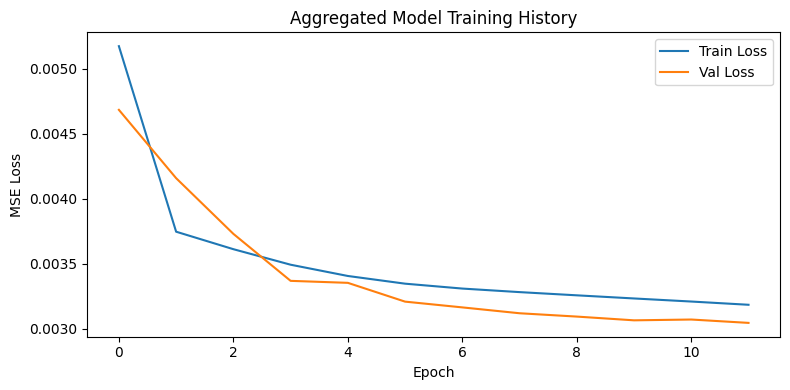

In [33]:
# ===============================
# 11. Plot training history
# ===============================
plt.figure(figsize=(8, 4))
plt.plot(history_agg.history["loss"], label="Train Loss")
plt.plot(history_agg.history["val_loss"], label="Val Loss")
plt.title("Aggregated Model Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "aggregated_training_history.png"))
plt.show()

In [34]:
# ===============================
# 12. Evaluate aggregated model
# ===============================
agg_rows = []

for pid, data in patient_splits.items():
    scaler = patient_scalers[pid]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = agg_model.predict(X_test, verbose=0)

    y_test_inv = inverse_glucose_only(y_test, scaler)
    y_pred_inv = inverse_glucose_only(y_pred, scaler)

    rmse = rmse_score(y_test_inv, y_pred_inv)
    zones = compute_clarke_percentages(y_test_inv, y_pred_inv)

    agg_rows.append({
        "patient_id": pid,
        "agg_rmse": rmse,
        "agg_zone_A": zones["A"],
        "agg_zone_B": zones["B"],
        "agg_zone_C": zones["C"],
        "agg_zone_D": zones["D"],
        "agg_zone_E": zones["E"]
    })

agg_df = pd.DataFrame(agg_rows).sort_values("patient_id").reset_index(drop=True)
display(agg_df.head())

print("Aggregated mean RMSE:", round(agg_df["agg_rmse"].mean(), 4))
print("Aggregated mean Zone A %:", round(agg_df["agg_zone_A"].mean(), 4))

,patient_id,agg_rmse,agg_zone_A,agg_zone_B,agg_zone_C,agg_zone_D,agg_zone_E
0,HUPA0001P,32.772707,81.198793,17.270375,0.377318,1.153514,0.0
1,HUPA0002P,18.047321,85.734463,13.968927,0.000000,0.296610,0.0
2,HUPA0003P,20.482986,79.702970,20.167374,0.035361,0.094295,0.0
3,HUPA0004P,23.440418,87.203390,12.245763,0.169492,0.381356,0.0
4,HUPA0005P,18.233753,89.896552,10.091954,0.000000,0.011494,0.0


Aggregated mean RMSE: 20.4308
Aggregated mean Zone A %: 85.9077


In [35]:
# ===============================
# 13. Train personalized models (BETTER BALANCED VERSION)
# ===============================

MAX_PERSONAL_PATIENTS = 5
selected_patient_ids = list(patient_splits.keys())[:MAX_PERSONAL_PATIENTS]

personal_rows = []

for idx, pid in enumerate(selected_patient_ids, start=1):
    data = patient_splits[pid]
    print(f"\n[{idx}/{len(selected_patient_ids)}] Training personalized model for {pid}")

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]

    scaler = patient_scalers[pid]
    model_path = os.path.join(SAVE_DIR, "models", f"{pid}_best.keras")

    model = build_model()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True, verbose=0)
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=32,
        verbose=0,
        callbacks=callbacks
    )

    model = load_model(model_path)
    y_pred = model.predict(X_test, verbose=0)

    y_test_inv = inverse_glucose_only(y_test, scaler)
    y_pred_inv = inverse_glucose_only(y_pred, scaler)

    rmse = rmse_score(y_test_inv, y_pred_inv)
    zones = compute_clarke_percentages(y_test_inv, y_pred_inv)

    personal_rows.append({
        "patient_id": pid,
        "personal_rmse": rmse,
        "personal_zone_A": zones["A"],
        "personal_zone_B": zones["B"],
        "personal_zone_C": zones["C"],
        "personal_zone_D": zones["D"],
        "personal_zone_E": zones["E"]
    })

personal_df = pd.DataFrame(personal_rows).sort_values("patient_id").reset_index(drop=True)
display(personal_df)

print("Personalized mean RMSE:", round(personal_df["personal_rmse"].mean(), 4))
print("Personalized mean Zone A %:", round(personal_df["personal_zone_A"].mean(), 4))


[1/5] Training personalized model for HUPA0001P

[2/5] Training personalized model for HUPA0002P

[3/5] Training personalized model for HUPA0003P

[4/5] Training personalized model for HUPA0004P

[5/5] Training personalized model for HUPA0005P


,patient_id,personal_rmse,personal_zone_A,personal_zone_B,personal_zone_C,personal_zone_D,personal_zone_E
0,HUPA0001P,33.610310,78.924105,19.297111,0.366537,1.412247,0.0
1,HUPA0002P,21.667330,81.850282,17.612994,0.028249,0.508475,0.0
2,HUPA0003P,23.252142,78.017445,21.534653,0.023574,0.424328,0.0
3,HUPA0004P,26.166416,86.850282,12.316384,0.014124,0.819209,0.0
4,HUPA0005P,19.233983,90.597701,9.333333,0.034483,0.034483,0.0


Personalized mean RMSE: 24.786
Personalized mean Zone A %: 83.248


In [ ]:
# ===============================
# 14. Compare aggregated vs personalized
# ===============================
results_df = agg_df.merge(personal_df, on="patient_id", how="inner")

results_df["rmse_diff_personal_minus_agg"] = results_df["personal_rmse"] - results_df["agg_rmse"]
results_df["zoneA_diff_personal_minus_agg"] = results_df["personal_zone_A"] - results_df["agg_zone_A"]

display(results_df.head())

print("\n========== FINAL SUMMARY ==========")
print("Patients compared:", len(results_df))
print("Mean aggregated RMSE:", round(results_df["agg_rmse"].mean(), 4))
print("Mean personalized RMSE:", round(results_df["personal_rmse"].mean(), 4))
print("Mean aggregated Zone A %:", round(results_df["agg_zone_A"].mean(), 4))
print("Mean personalized Zone A %:", round(results_df["personal_zone_A"].mean(), 4))

In [ ]:
# ===============================
# 15. Save result tables
# ===============================
agg_df.to_csv(os.path.join(SAVE_DIR, "tables", "aggregated_results.csv"), index=False)
personal_df.to_csv(os.path.join(SAVE_DIR, "tables", "personalized_results.csv"), index=False)
results_df.to_csv(os.path.join(SAVE_DIR, "tables", "comparison_results.csv"), index=False)

print("Saved tables in:", os.path.join(SAVE_DIR, "tables"))

In [ ]:
# ===============================
# 16. RMSE bar plot
# ===============================
plot_df = results_df.sort_values("agg_rmse").reset_index(drop=True)

x = np.arange(len(plot_df))
w = 0.4

plt.figure(figsize=(14, 5))
plt.bar(x - w/2, plot_df["agg_rmse"], width=w, label="Aggregated")
plt.bar(x + w/2, plot_df["personal_rmse"], width=w, label="Personalized")
plt.xticks(x, plot_df["patient_id"], rotation=90)
plt.ylabel("RMSE (mg/dL)")
plt.title("RMSE Comparison: Aggregated vs Personalized")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "rmse_bar_comparison.png"))
plt.show()

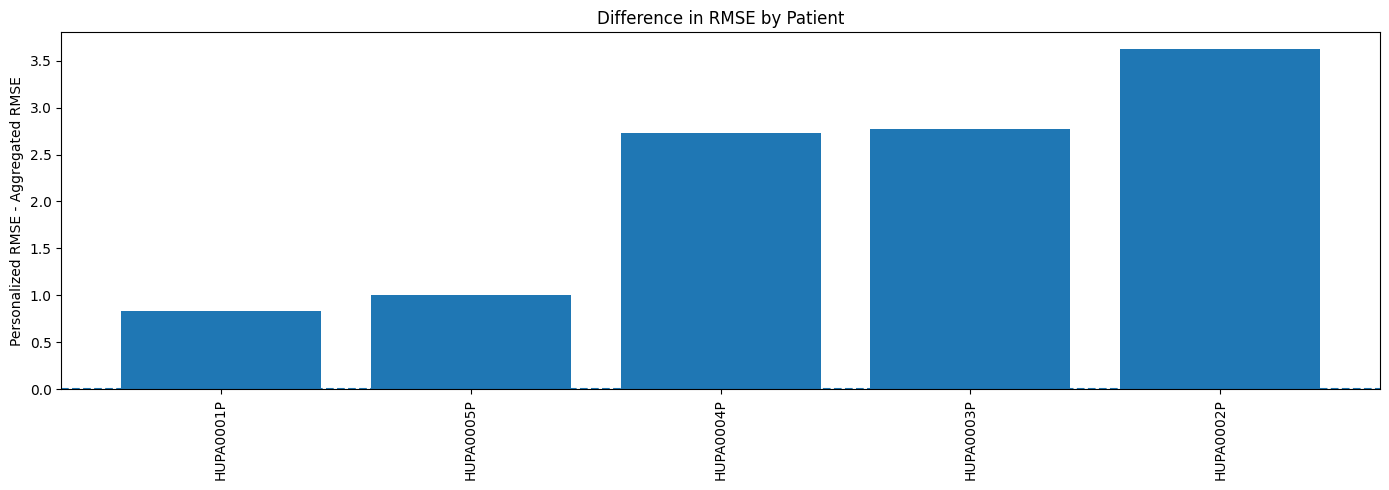

In [39]:
# ===============================
# 17. RMSE difference plot
# ===============================
plot_df2 = results_df.sort_values("rmse_diff_personal_minus_agg").reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.bar(plot_df2["patient_id"], plot_df2["rmse_diff_personal_minus_agg"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=90)
plt.ylabel("Personalized RMSE - Aggregated RMSE")
plt.title("Difference in RMSE by Patient")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "rmse_difference.png"))
plt.show()

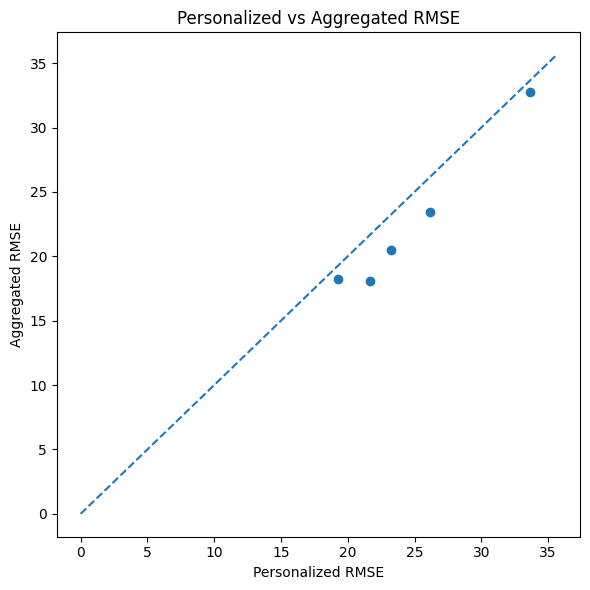

In [40]:
# ===============================
# 18. RMSE scatterplot
# ===============================
mx = max(results_df["agg_rmse"].max(), results_df["personal_rmse"].max()) + 2

plt.figure(figsize=(6, 6))
plt.scatter(results_df["personal_rmse"], results_df["agg_rmse"])
plt.plot([0, mx], [0, mx], linestyle="--")
plt.xlabel("Personalized RMSE")
plt.ylabel("Aggregated RMSE")
plt.title("Personalized vs Aggregated RMSE")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "rmse_scatter.png"))
plt.show()

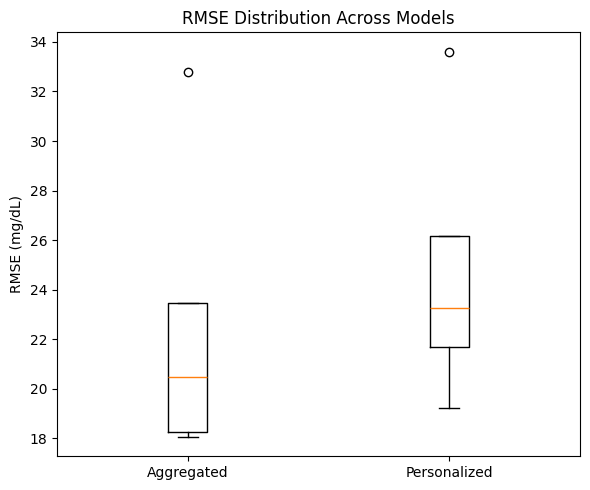

In [41]:
# ===============================
# 19. RMSE boxplot
# ===============================
plt.figure(figsize=(6, 5))
plt.boxplot([results_df["agg_rmse"], results_df["personal_rmse"]],
            labels=["Aggregated", "Personalized"])
plt.ylabel("RMSE (mg/dL)")
plt.title("RMSE Distribution Across Models")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "rmse_boxplot.png"))
plt.show()

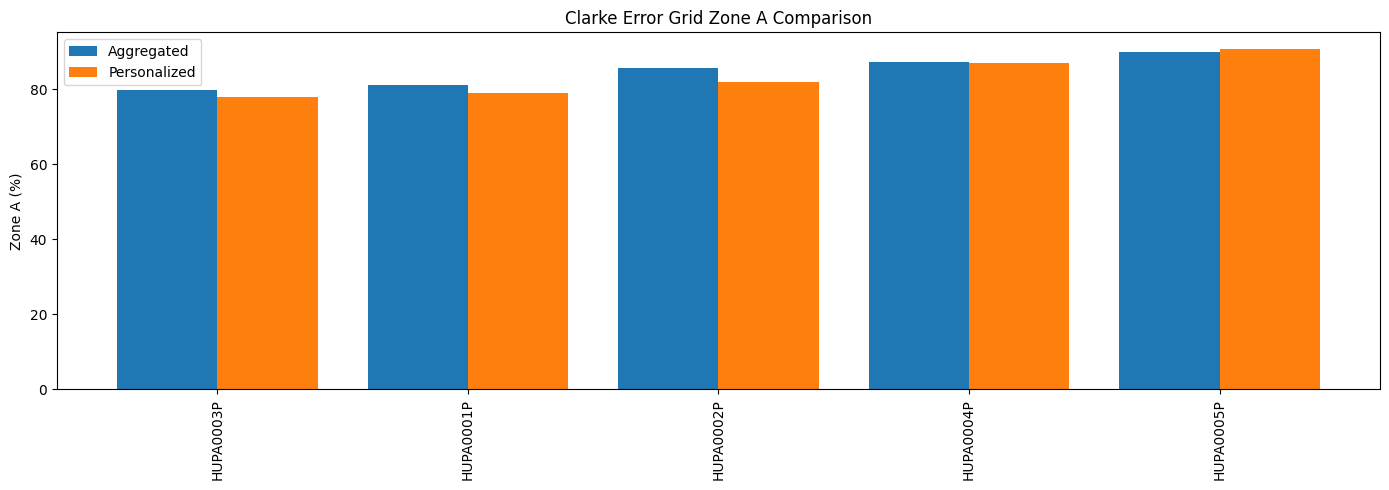

In [42]:
# ===============================
# 20. Zone A comparison
# ===============================
plot_df3 = results_df.sort_values("agg_zone_A").reset_index(drop=True)
x = np.arange(len(plot_df3))
w = 0.4

plt.figure(figsize=(14, 5))
plt.bar(x - w/2, plot_df3["agg_zone_A"], width=w, label="Aggregated")
plt.bar(x + w/2, plot_df3["personal_zone_A"], width=w, label="Personalized")
plt.xticks(x, plot_df3["patient_id"], rotation=90)
plt.ylabel("Zone A (%)")
plt.title("Clarke Error Grid Zone A Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", "zoneA_bar_comparison.png"))
plt.show()

Example patient: HUPA0001P


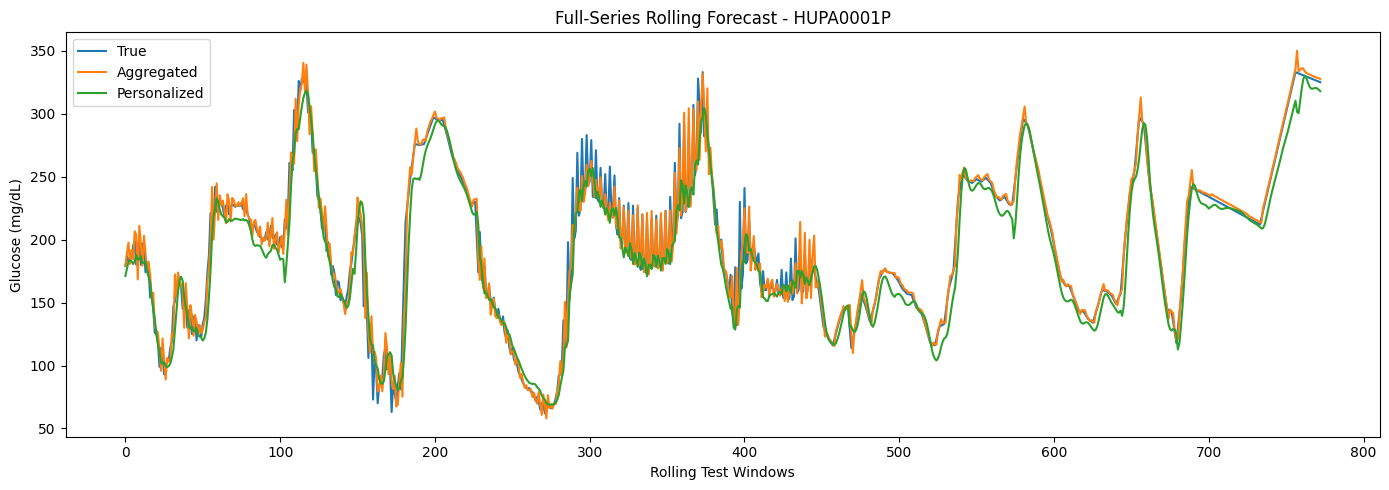

In [43]:
# ===============================
# 21. Full-series rolling forecast for one patient
# ===============================
example_pid = results_df.iloc[0]["patient_id"]
print("Example patient:", example_pid)

data = patient_splits[example_pid]
scaler = patient_scalers[example_pid]

# aggregated prediction
X_test = data["X_test"]
y_test = data["y_test"]

agg_pred = agg_model.predict(X_test, verbose=0)
agg_true_inv = inverse_glucose_only(y_test, scaler)
agg_pred_inv = inverse_glucose_only(agg_pred, scaler)

# personalized prediction
personal_model_path = os.path.join(SAVE_DIR, "models", f"{example_pid}_best.keras")
personal_model = load_model(personal_model_path)
per_pred = personal_model.predict(X_test, verbose=0)
per_pred_inv = inverse_glucose_only(per_pred, scaler)

# Use first prediction point from each rolling window for continuous-looking plot
true_series = agg_true_inv[:, 0]
agg_series = agg_pred_inv[:, 0]
per_series = per_pred_inv[:, 0]

plt.figure(figsize=(14, 5))
plt.plot(true_series, label="True")
plt.plot(agg_series, label="Aggregated")
plt.plot(per_series, label="Personalized")
plt.xlabel("Rolling Test Windows")
plt.ylabel("Glucose (mg/dL)")
plt.title(f"Full-Series Rolling Forecast - {example_pid}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", f"{example_pid}_full_series_forecast.png"))
plt.show()

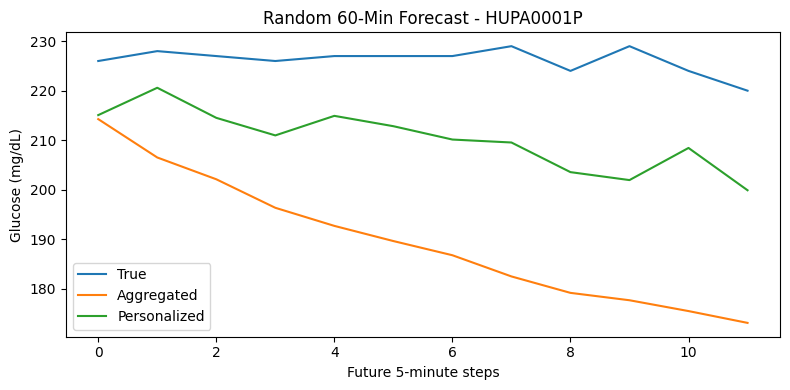

In [44]:
# ===============================
# 22. Random 60-min forecast window
# ===============================
rng = np.random.default_rng(SEED)
sample_idx = int(rng.integers(0, len(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(agg_true_inv[sample_idx], label="True")
plt.plot(agg_pred_inv[sample_idx], label="Aggregated")
plt.plot(per_pred_inv[sample_idx], label="Personalized")
plt.xlabel("Future 5-minute steps")
plt.ylabel("Glucose (mg/dL)")
plt.title(f"Random 60-Min Forecast - {example_pid}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "plots", f"{example_pid}_random_60min_forecast.png"))
plt.show()

In [45]:
# ===============================
# 23. Final summary report
# ===============================
summary = {
    "num_patients": int(len(results_df)),
    "aggregated_mean_rmse": float(results_df["agg_rmse"].mean()),
    "personalized_mean_rmse": float(results_df["personal_rmse"].mean()),
    "aggregated_mean_zone_A": float(results_df["agg_zone_A"].mean()),
    "personalized_mean_zone_A": float(results_df["personal_zone_A"].mean()),
    "fast_mode": FAST_MODE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE
}

print(json.dumps(summary, indent=2))

with open(os.path.join(SAVE_DIR, "tables", "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nEverything saved under:", SAVE_DIR)

{
  "num_patients": 5,
  "aggregated_mean_rmse": 22.595436768446792,
  "personalized_mean_rmse": 24.786036244169715,
  "aggregated_mean_zone_A": 84.74723354230443,
  "personalized_mean_zone_A": 83.2479631881092,
  "fast_mode": true,
  "epochs": 12,
  "batch_size": 64,
  "patience": 3
}

Everything saved under: /content/hupa_outputs
